In [19]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import matplotlib.pyplot as plt

In [20]:
df = pd.read_csv("happy_merged.csv", skiprows=15)

print(df.head())

          Date/Time  100m_N Avg [m/s]  100m_S Avg [m/s]  80m Avg [m/s]  \
0  01-12-2018 00:00            10.654            10.809          5.182   
1  01-12-2018 00:10            10.531            10.688          5.334   
2  01-12-2018 00:20             9.976            10.110          5.319   
3  01-12-2018 00:30             9.617             9.735          5.319   
4  01-12-2018 00:40             9.001             9.112          5.363   

   50m Avg [m/s]  20m Avg [m/s]  10m Avg [m/s]  Pressure 5m [mbar]  \
0          7.096          4.852            NaN              1012.2   
1          7.415          4.953            NaN              1012.1   
2          7.398          4.796            NaN              1012.2   
3          7.430          4.749            NaN              1012.1   
4          7.344          4.833            NaN              1012.0   

   98m WV [?]  78m WV [?]  48m WV [?]  Temp 5m [?C]  Hum 5m  
0        52.0        45.0        29.5          22.5    46.5  
1        5

In [21]:
data = df[['50m Avg [m/s]', '100m_N Avg [m/s]']]

data = data.dropna()

print(data.head())

   50m Avg [m/s]  100m_N Avg [m/s]
0          7.096            10.654
1          7.415            10.531
2          7.398             9.976
3          7.430             9.617
4          7.344             9.001


In [22]:
X = data[['50m Avg [m/s]']].values

y = data['100m_N Avg [m/s]'].values

In [23]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X = scaler_X.fit_transform(X)

y = scaler_y.fit_transform(
    y.reshape(-1,1)
)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

In [25]:
X_train = X_train.reshape(
    X_train.shape[0],
    1,
    X_train.shape[1]
)

X_test = X_test.reshape(
    X_test.shape[0],
    1,
    X_test.shape[1]
)

print(X_train.shape)
print(X_test.shape)

(36750, 1, 1)
(15751, 1, 1)


In [26]:
model = Sequential()

model.add(
    LSTM(
        50,
        activation='relu',
        input_shape=(1,1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()

C:\Users\DHARINI S\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.0120 - val_loss: 0.0031
Epoch 2/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0031 - val_loss: 0.0030
Epoch 3/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0029 - val_loss: 0.0028
Epoch 4/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 5/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 6/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 7/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 8/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 9/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 10/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 11/50
1149/1149 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0028 - val_loss: 0.0028
Epoch 12/50
1149/1149 ━━━━━━━

In [28]:
y_pred = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred)
y_test_actual = scaler_y.inverse_transform(y_test)

print("Prediction completed")

493/493 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Prediction completed


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_actual, y_pred)
mse = mean_squared_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.7645066327210737
MSE : 1.0063296571224167
RMSE: 1.0031598362785548
R²  : 0.8789201040921757


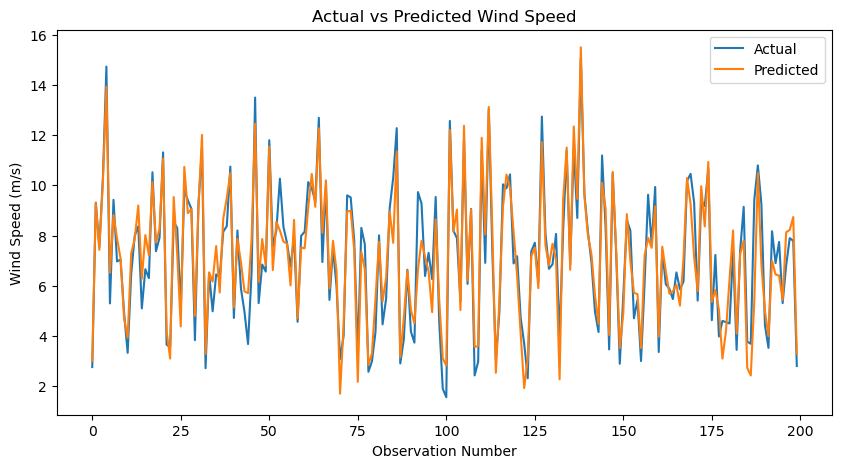

In [30]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')

plt.title('Actual vs Predicted Wind Speed')
plt.xlabel('Observation Number')
plt.ylabel('Wind Speed (m/s)')
plt.legend()

plt.show()

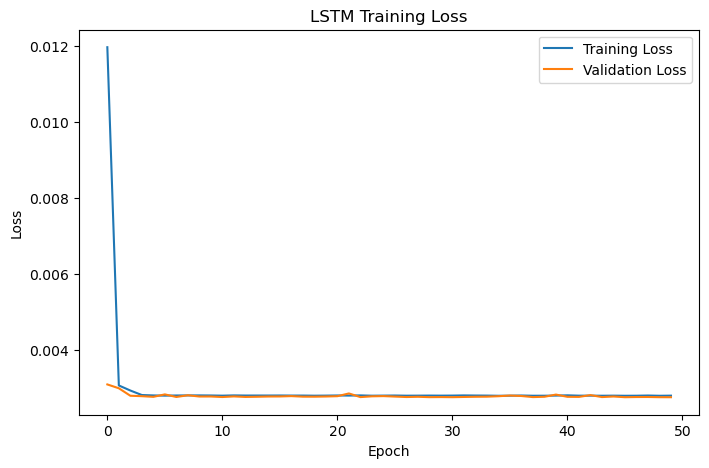

In [31]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [32]:
comparison = pd.DataFrame({
    'Actual': y_test_actual.flatten(),
    'Predicted': y_pred.flatten()
})

comparison.head(20)

,Actual,Predicted
0,2.764,3.010450
1,9.312,9.296496
2,7.538,7.430407
3,10.270,10.144805
4,14.728,13.930639
5,5.298,6.521438
6,9.422,8.818383
7,6.970,7.895654
8,7.043,7.081593
9,4.908,4.693244
